In [2]:
# ================================
# GTZAN COMPLETE PIPELINE
# Preprocess 3-sec + 30-sec
# Train models
# Compare results
# Save classification reports
# Save confusion matrices
# ================================

import os
import re
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.impute import SimpleImputer

from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.metrics import accuracy_score, f1_score, classification_report, confusion_matrix, ConfusionMatrixDisplay


In [3]:
# ================================
# GLOBAL SETTINGS
# ================================

TEST_SIZE = 0.2
RANDOM_STATE = 42


# ================================
# PREPROCESSING FUNCTION
# ================================

def preprocess_gtzan_csv(INPUT_CSV: str, OUT_PREFIX: str,
                         label_col="label",
                         fname_col="filename"):

    print(f"\n=== Preprocessing {INPUT_CSV} ===")

    df = pd.read_csv(INPUT_CSV)

    def _make_song_id_from_filename(fname: str) -> str:
        base = str(fname).split("/")[-1]
        base = re.sub(r"\.wav$", "", base)

        # For GTZAN 3-sec files like: blues.00000.13
        # we want all segments grouped as: blues.00000
        parts = base.split(".")
        if len(parts) >= 3 and parts[-1].isdigit():
            return ".".join(parts[:-1])

        # For 30-sec files like: blues.00000
        return base

    df["song_id"] = df[fname_col].astype(str).apply(_make_song_id_from_filename)

    # Separate features and labels
    drop_cols = [label_col, fname_col, "song_id"]
    y_raw = df[label_col].astype(str).values
    song_ids = df["song_id"].astype(str).values

    X = df.drop(columns=drop_cols, errors="ignore")
    X = X.apply(pd.to_numeric, errors="coerce")
    X = X.dropna(axis=1, how="all")

    # Encode labels
    le = LabelEncoder()
    y = le.fit_transform(y_raw)

    # Save class names for later reports
    np.save(f"{OUT_PREFIX}_class_names.npy", le.classes_)

    # Leakage-safe split by song_id
    unique_songs = pd.unique(song_ids)

    song_to_label = {}
    for sid, lab in zip(song_ids, y):
        if sid not in song_to_label:
            song_to_label[sid] = lab

    song_labels = np.array([song_to_label[s] for s in unique_songs])

    train_songs, test_songs = train_test_split(
        unique_songs,
        test_size=TEST_SIZE,
        random_state=RANDOM_STATE,
        stratify=song_labels
    )

    train_mask = np.isin(song_ids, train_songs)
    test_mask = np.isin(song_ids, test_songs)

    X_train = X.values[train_mask]
    X_test = X.values[test_mask]
    y_train = y[train_mask]
    y_test = y[test_mask]
    song_train = song_ids[train_mask]
    song_test = song_ids[test_mask]

    # Impute missing values
    imputer = SimpleImputer(strategy="median")
    X_train_imp = imputer.fit_transform(X_train)
    X_test_imp = imputer.transform(X_test)

    # Standardize
    scaler = StandardScaler()
    X_train_scaled = scaler.fit_transform(X_train_imp)
    X_test_scaled = scaler.transform(X_test_imp)

    # Save arrays
    np.save(f"{OUT_PREFIX}_X_train.npy", X_train_scaled)
    np.save(f"{OUT_PREFIX}_X_test.npy", X_test_scaled)
    np.save(f"{OUT_PREFIX}_y_train.npy", y_train)
    np.save(f"{OUT_PREFIX}_y_test.npy", y_test)
    np.save(f"{OUT_PREFIX}_song_train.npy", song_train)
    np.save(f"{OUT_PREFIX}_song_test.npy", song_test)

    print(f"[{OUT_PREFIX}] Saved arrays.")
    print("Train label counts:", np.bincount(y_train))
    print("Test label counts: ", np.bincount(y_test))




In [4]:
# ================================
# REPORT / CM HELPERS
# ================================

def save_classification_report_csv(y_true, y_pred, class_names, out_path):
    report_dict = classification_report(
        y_true,
        y_pred,
        target_names=class_names,
        output_dict=True,
        zero_division=0
    )
    report_df = pd.DataFrame(report_dict).transpose()
    report_df.to_csv(out_path, index=True)


def save_confusion_matrix_csv(y_true, y_pred, class_names, out_path):
    cm = confusion_matrix(y_true, y_pred)
    cm_df = pd.DataFrame(cm, index=class_names, columns=class_names)
    cm_df.to_csv(out_path, index=True)


def save_confusion_matrix_plot(y_true, y_pred, class_names, out_path, title):
    cm = confusion_matrix(y_true, y_pred)

    fig, ax = plt.subplots(figsize=(8, 8))
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=class_names)
    disp.plot(ax=ax, xticks_rotation=45, colorbar=False)
    ax.set_title(title)
    plt.tight_layout()
    plt.savefig(out_path, dpi=200, bbox_inches="tight")
    plt.close()

In [5]:
# ================================
# MODEL TRAINING + EVALUATION
# ================================

def get_models():
    return {
        "LogReg": LogisticRegression(max_iter=4000),
        "SVM_RBF": SVC(kernel="rbf", C=10, gamma="scale"),
        "RandomForest": RandomForestClassifier(n_estimators=400, random_state=42),
        "GradBoost": GradientBoostingClassifier(random_state=42),
    }


def run_experiment(prefix: str, dataset_name: str, song_level=False):
    X_train, X_test, y_train, y_test, song_test, class_names = load_split(prefix)
    rows = []

    os.makedirs("reports", exist_ok=True)
    os.makedirs("confusion_matrices", exist_ok=True)

    for name, model in get_models().items():
        print(f"\n--- Training {name} on {dataset_name} ---")

        model.fit(X_train, y_train)
        y_pred = model.predict(X_test)

        # Row-level metrics
        m = compute_metrics(y_test, y_pred)
        rows.append({
            "dataset": dataset_name,
            "evaluation": "row_level",
            "model": name,
            **m
        })

        print(f"\n=== {dataset_name} | {name} | row_level ===")
        print(classification_report(
            y_test,
            y_pred,
            target_names=class_names,
            zero_division=0
        ))

        print_confusion_matrix(
            y_test,
            y_pred,
            class_names,
            title=f"{dataset_name} - {name} - Row Level"
        )

        save_classification_report_csv(
            y_test,
            y_pred,
            class_names,
            f"reports/{dataset_name}_{name}_row_level_report.csv"
        )

        save_confusion_matrix_csv(
            y_test,
            y_pred,
            class_names,
            f"confusion_matrices/{dataset_name}_{name}_row_level_cm.csv"
        )

        save_confusion_matrix_plot(
            y_test,
            y_pred,
            class_names,
            f"confusion_matrices/{dataset_name}_{name}_row_level_cm.png",
            title=f"{dataset_name} - {name} - Row Level"
        )

        # Song-level metrics for 3-sec dataset
        if song_level:
            y_song_true, y_song_pred = majority_vote(y_pred, y_test, song_test)

            m_song = compute_metrics(y_song_true, y_song_pred)
            rows.append({
                "dataset": dataset_name,
                "evaluation": "song_majority_vote",
                "model": name,
                **m_song
            })

            #Print the classification report
            print(f"\n=== {dataset_name} | {name} | song_majority_vote ===")
            print(classification_report(
                y_song_true,
                y_song_pred,
                target_names=class_names,
                zero_division=0
            ))

            # Print the confusion matrix
            print_confusion_matrix(
                y_song_true,
                y_song_pred,
                class_names,
                title=f"{dataset_name} - {name} - Song Majority Vote"
            )

            save_classification_report_csv(
                y_song_true,
                y_song_pred,
                class_names,
                f"reports/{dataset_name}_{name}_song_level_report.csv"
            )

            save_confusion_matrix_csv(
                y_song_true,
                y_song_pred,
                class_names,
                f"confusion_matrices/{dataset_name}_{name}_song_level_cm.csv"
            )

            save_confusion_matrix_plot(
                y_song_true,
                y_song_pred,
                class_names,
                f"confusion_matrices/{dataset_name}_{name}_song_level_cm.png",
                title=f"{dataset_name} - {name} - Song Majority Vote"
            )

    return pd.DataFrame(rows)


In [6]:
# ================================
# HELPERS
# ================================
def print_confusion_matrix(y_true, y_pred, class_names, title):
    cm = confusion_matrix(y_true, y_pred)
    fig, ax = plt.subplots(figsize=(8, 8))
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=class_names)
    disp.plot(ax=ax, xticks_rotation=45, colorbar=False)
    ax.set_title(title)
    plt.tight_layout()
    plt.show()

def load_split(prefix: str):
    X_train = np.load(f"{prefix}_X_train.npy")
    X_test = np.load(f"{prefix}_X_test.npy")
    y_train = np.load(f"{prefix}_y_train.npy")
    y_test = np.load(f"{prefix}_y_test.npy")
    song_test = np.load(f"{prefix}_song_test.npy", allow_pickle=True)
    class_names = np.load(f"{prefix}_class_names.npy", allow_pickle=True)
    return X_train, X_test, y_train, y_test, song_test, class_names

def compute_metrics(y_true, y_pred):
    accuracy = accuracy_score(y_true, y_pred)
    f1_macro = f1_score(y_true, y_pred, average="macro", zero_division=0)
    return {"accuracy": accuracy, "macro_f1": f1_macro}

def majority_vote(y_pred, y_true, song_test):
    df_pred = pd.DataFrame({"song_id": song_test, "y_pred": y_pred, "y_true": y_true})
    song_preds = df_pred.groupby("song_id").agg(
        y_pred_mode=('y_pred', lambda x: x.mode()[0]),
        y_true_first=('y_true', 'first')
    )
    return song_preds["y_true_first"].values, song_preds["y_pred_mode"].values


=== Preprocessing features_3_sec.csv ===
[gtzan_3sec] Saved arrays.
Train label counts: [800 798 797 799 798 800 800 800 800 798]
Test label counts:  [200 200 200 200 200 200 200 200 200 200]

=== Preprocessing features_30_sec.csv ===
[gtzan_30sec] Saved arrays.
Train label counts: [80 80 80 80 80 80 80 80 80 80]
Test label counts:  [20 20 20 20 20 20 20 20 20 20]

--- Training LogReg on 3_sec_features ---

=== 3_sec_features | LogReg | row_level ===
              precision    recall  f1-score   support

       blues       0.62      0.64      0.63       200
   classical       0.89      0.92      0.91       200
     country       0.62      0.61      0.62       200
       disco       0.67      0.50      0.57       200
      hiphop       0.60      0.58      0.59       200
        jazz       0.70      0.83      0.76       200
       metal       0.82      0.77      0.79       200
         pop       0.70      0.72      0.71       200
      reggae       0.57      0.67      0.62       200
   

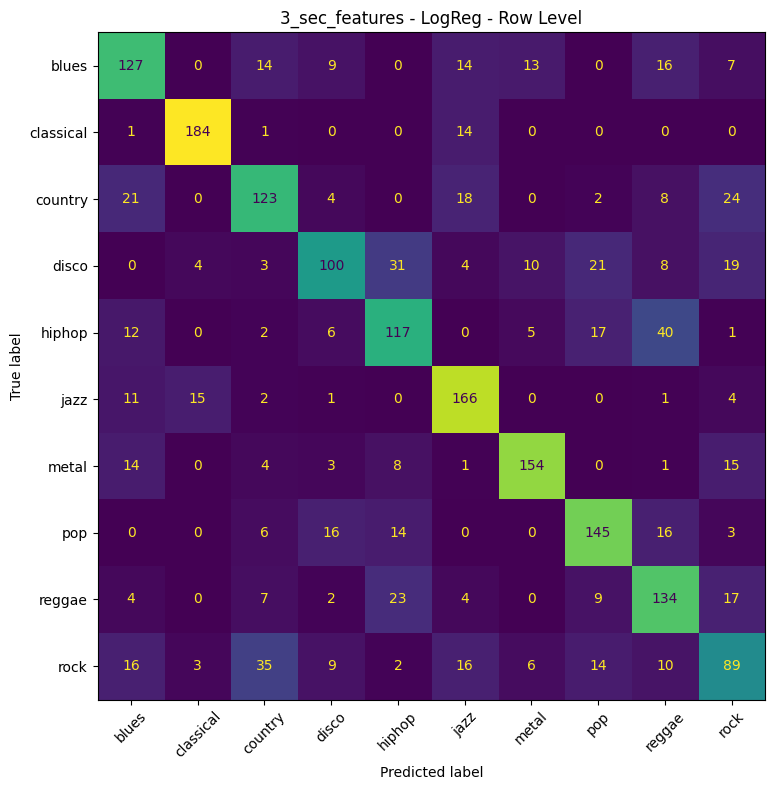


=== 3_sec_features | LogReg | song_majority_vote ===
              precision    recall  f1-score   support

       blues       0.70      0.80      0.74        20
   classical       0.91      1.00      0.95        20
     country       0.70      0.70      0.70        20
       disco       0.92      0.55      0.69        20
      hiphop       0.64      0.70      0.67        20
        jazz       0.82      0.90      0.86        20
       metal       0.90      0.90      0.90        20
         pop       0.74      0.85      0.79        20
      reggae       0.65      0.75      0.70        20
        rock       0.69      0.45      0.55        20

    accuracy                           0.76       200
   macro avg       0.77      0.76      0.75       200
weighted avg       0.77      0.76      0.75       200



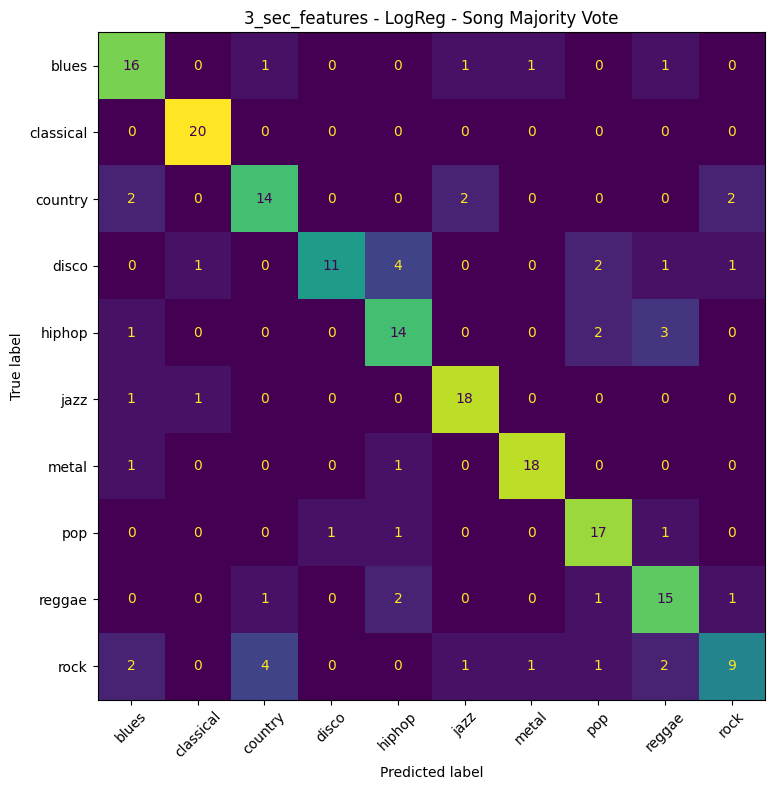


--- Training SVM_RBF on 3_sec_features ---

=== 3_sec_features | SVM_RBF | row_level ===
              precision    recall  f1-score   support

       blues       0.72      0.79      0.75       200
   classical       0.78      0.95      0.86       200
     country       0.71      0.75      0.73       200
       disco       0.71      0.58      0.64       200
      hiphop       0.70      0.78      0.73       200
        jazz       0.76      0.80      0.78       200
       metal       0.92      0.78      0.85       200
         pop       0.66      0.66      0.66       200
      reggae       0.68      0.69      0.69       200
        rock       0.71      0.57      0.63       200

    accuracy                           0.73      2000
   macro avg       0.74      0.73      0.73      2000
weighted avg       0.74      0.73      0.73      2000



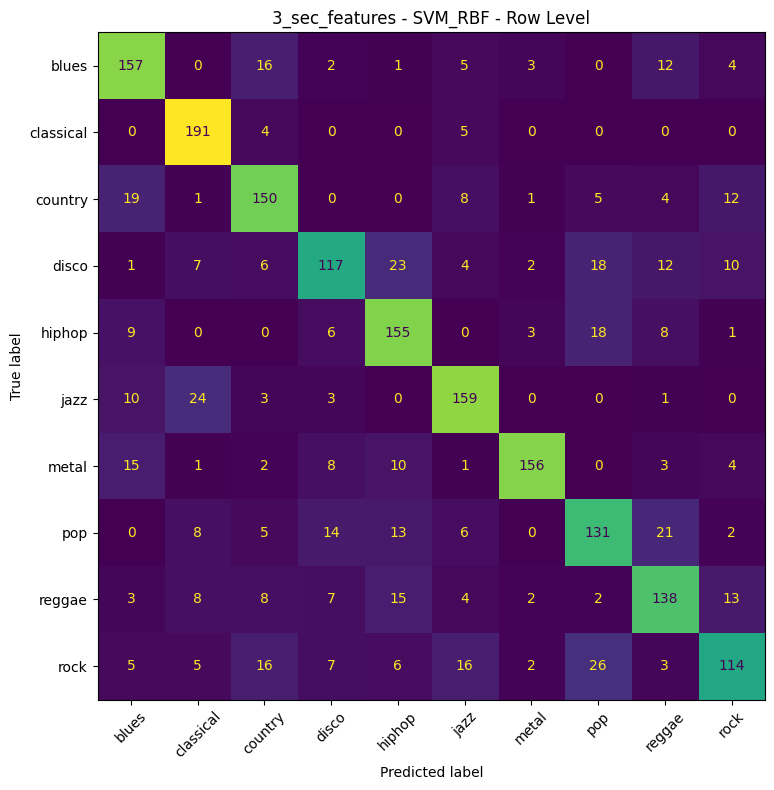


=== 3_sec_features | SVM_RBF | song_majority_vote ===
              precision    recall  f1-score   support

       blues       0.83      1.00      0.91        20
   classical       0.80      1.00      0.89        20
     country       0.82      0.90      0.86        20
       disco       0.88      0.70      0.78        20
      hiphop       0.81      0.85      0.83        20
        jazz       0.85      0.85      0.85        20
       metal       1.00      0.90      0.95        20
         pop       0.70      0.70      0.70        20
      reggae       0.79      0.75      0.77        20
        rock       0.87      0.65      0.74        20

    accuracy                           0.83       200
   macro avg       0.83      0.83      0.83       200
weighted avg       0.83      0.83      0.83       200



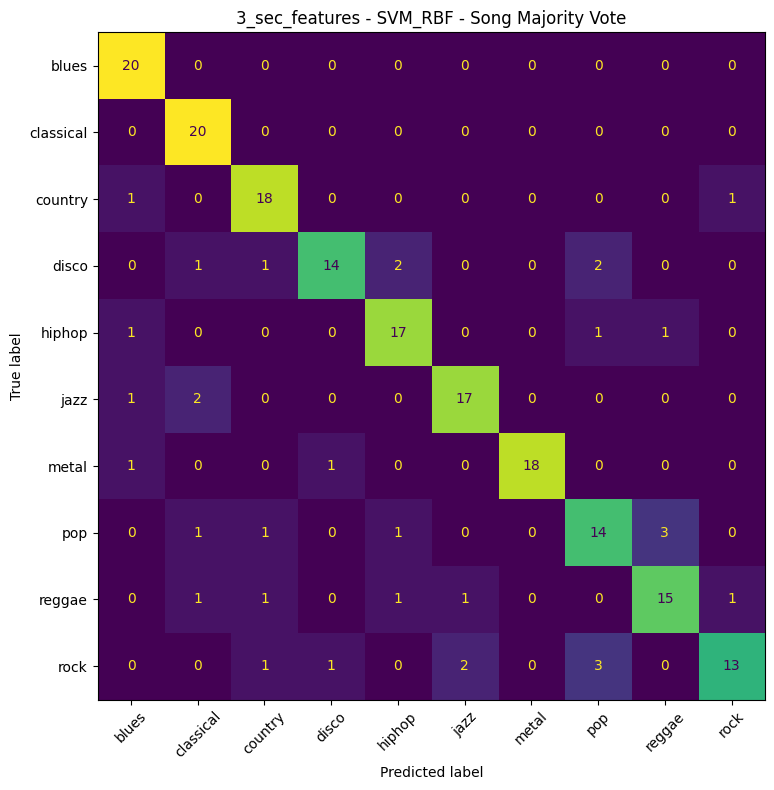


--- Training RandomForest on 3_sec_features ---

=== 3_sec_features | RandomForest | row_level ===
              precision    recall  f1-score   support

       blues       0.75      0.68      0.71       200
   classical       0.89      0.95      0.92       200
     country       0.69      0.72      0.70       200
       disco       0.66      0.53      0.58       200
      hiphop       0.63      0.71      0.67       200
        jazz       0.71      0.84      0.77       200
       metal       0.83      0.83      0.83       200
         pop       0.72      0.75      0.74       200
      reggae       0.64      0.65      0.64       200
        rock       0.66      0.53      0.59       200

    accuracy                           0.72      2000
   macro avg       0.72      0.72      0.71      2000
weighted avg       0.72      0.72      0.71      2000



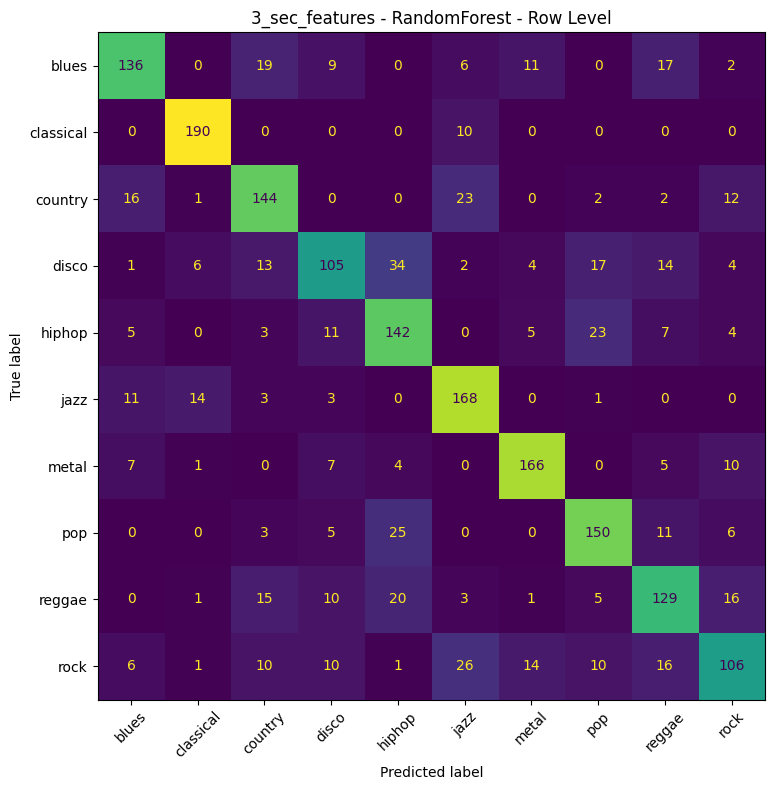


=== 3_sec_features | RandomForest | song_majority_vote ===
              precision    recall  f1-score   support

       blues       0.83      0.75      0.79        20
   classical       0.91      1.00      0.95        20
     country       0.78      0.90      0.84        20
       disco       0.72      0.65      0.68        20
      hiphop       0.70      0.70      0.70        20
        jazz       0.82      0.90      0.86        20
       metal       0.90      0.90      0.90        20
         pop       0.75      0.75      0.75        20
      reggae       0.59      0.65      0.62        20
        rock       0.80      0.60      0.69        20

    accuracy                           0.78       200
   macro avg       0.78      0.78      0.78       200
weighted avg       0.78      0.78      0.78       200



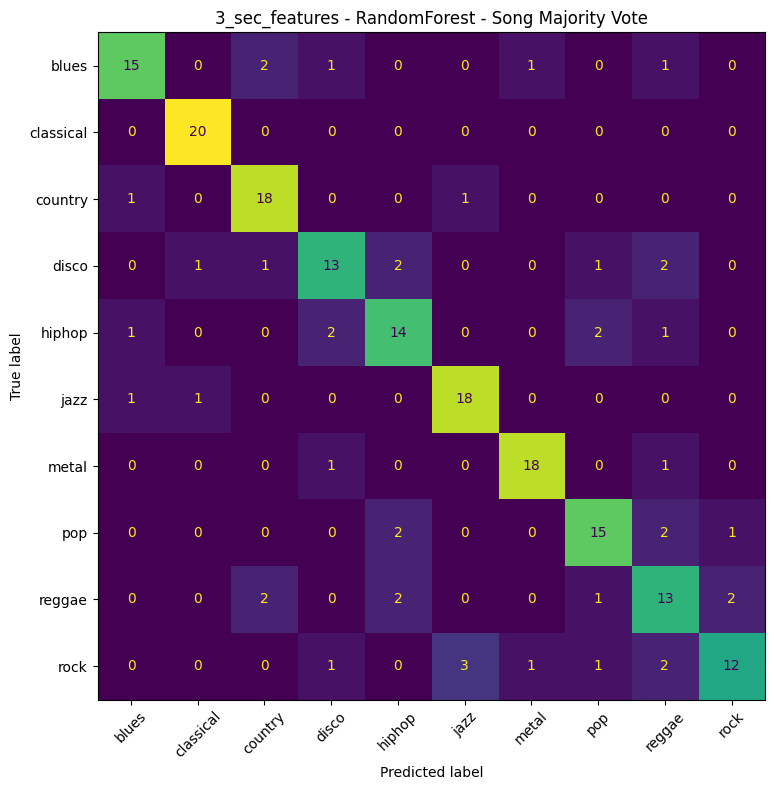


--- Training GradBoost on 3_sec_features ---

=== 3_sec_features | GradBoost | row_level ===
              precision    recall  f1-score   support

       blues       0.75      0.70      0.72       200
   classical       0.91      0.94      0.93       200
     country       0.63      0.72      0.67       200
       disco       0.65      0.55      0.60       200
      hiphop       0.66      0.73      0.69       200
        jazz       0.72      0.83      0.77       200
       metal       0.85      0.78      0.81       200
         pop       0.70      0.69      0.69       200
      reggae       0.65      0.66      0.65       200
        rock       0.64      0.56      0.60       200

    accuracy                           0.72      2000
   macro avg       0.72      0.72      0.71      2000
weighted avg       0.72      0.72      0.71      2000



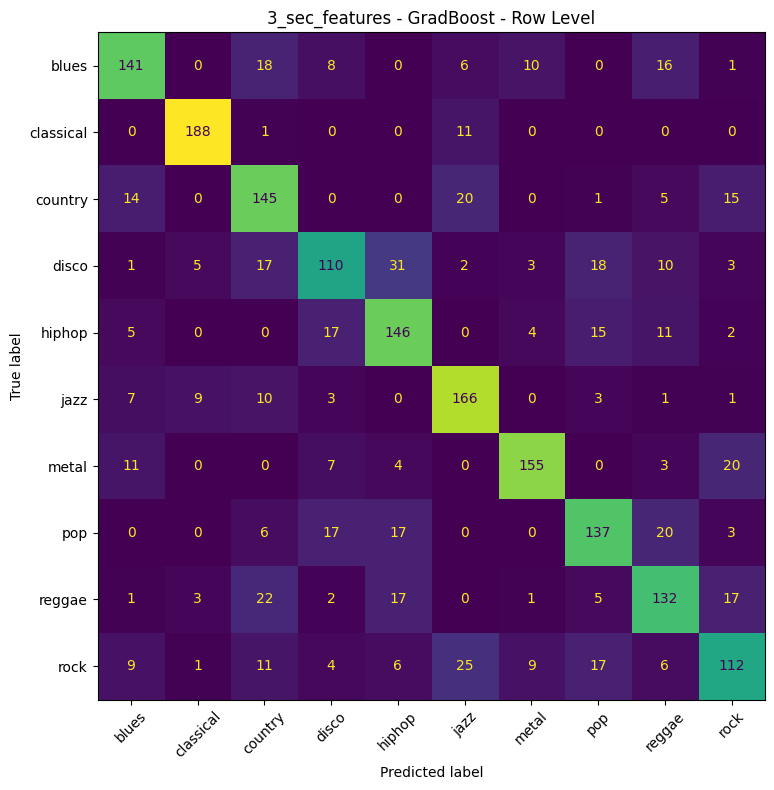


=== 3_sec_features | GradBoost | song_majority_vote ===
              precision    recall  f1-score   support

       blues       0.89      0.85      0.87        20
   classical       0.91      1.00      0.95        20
     country       0.79      0.95      0.86        20
       disco       0.63      0.60      0.62        20
      hiphop       0.74      0.85      0.79        20
        jazz       0.90      0.90      0.90        20
       metal       0.94      0.85      0.89        20
         pop       0.72      0.65      0.68        20
      reggae       0.71      0.75      0.73        20
        rock       0.81      0.65      0.72        20

    accuracy                           0.81       200
   macro avg       0.81      0.81      0.80       200
weighted avg       0.81      0.81      0.80       200



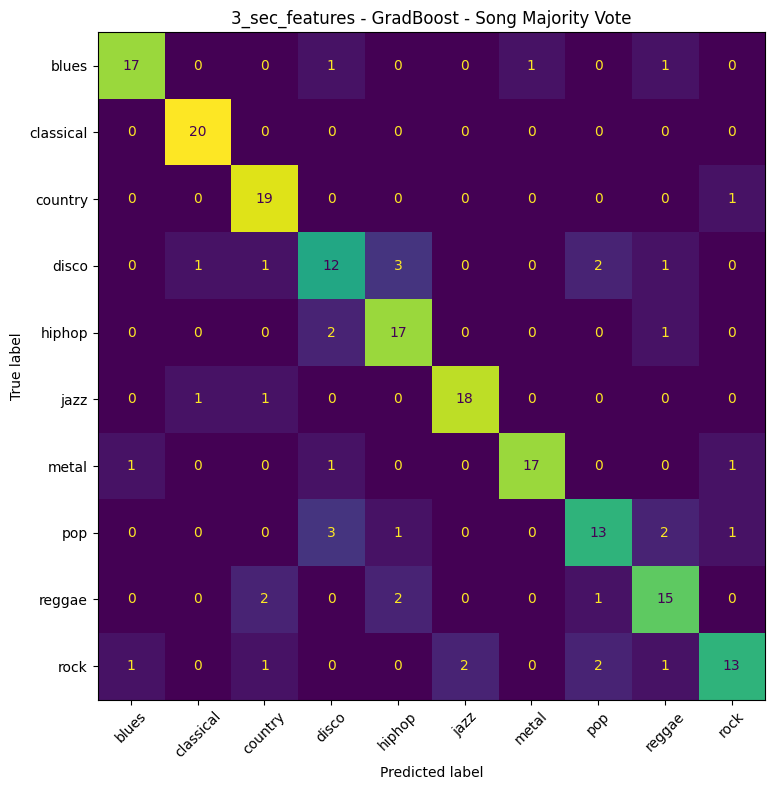


--- Training LogReg on 30_sec_features ---

=== 30_sec_features | LogReg | row_level ===
              precision    recall  f1-score   support

       blues       0.68      0.75      0.71        20
   classical       0.95      0.95      0.95        20
     country       0.70      0.70      0.70        20
       disco       0.85      0.55      0.67        20
      hiphop       0.76      0.65      0.70        20
        jazz       0.71      0.85      0.77        20
       metal       0.94      0.75      0.83        20
         pop       0.81      0.85      0.83        20
      reggae       0.62      0.80      0.70        20
        rock       0.52      0.55      0.54        20

    accuracy                           0.74       200
   macro avg       0.75      0.74      0.74       200
weighted avg       0.75      0.74      0.74       200



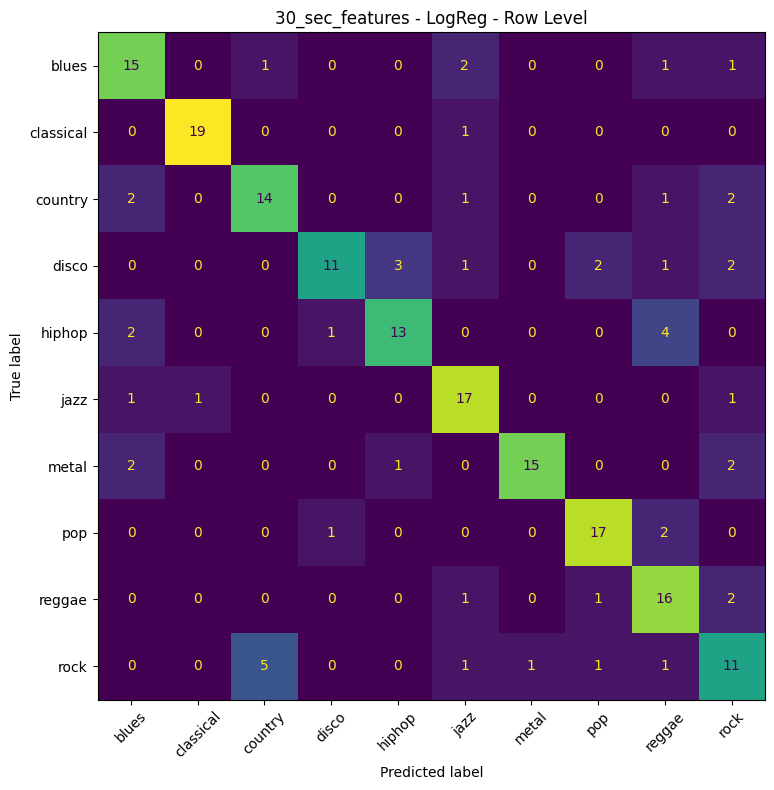


--- Training SVM_RBF on 30_sec_features ---

=== 30_sec_features | SVM_RBF | row_level ===
              precision    recall  f1-score   support

       blues       0.77      0.85      0.81        20
   classical       0.74      0.85      0.79        20
     country       0.85      0.85      0.85        20
       disco       0.65      0.55      0.59        20
      hiphop       0.89      0.80      0.84        20
        jazz       0.77      0.85      0.81        20
       metal       0.94      0.80      0.86        20
         pop       0.70      0.70      0.70        20
      reggae       0.65      0.75      0.70        20
        rock       0.72      0.65      0.68        20

    accuracy                           0.77       200
   macro avg       0.77      0.77      0.76       200
weighted avg       0.77      0.77      0.76       200



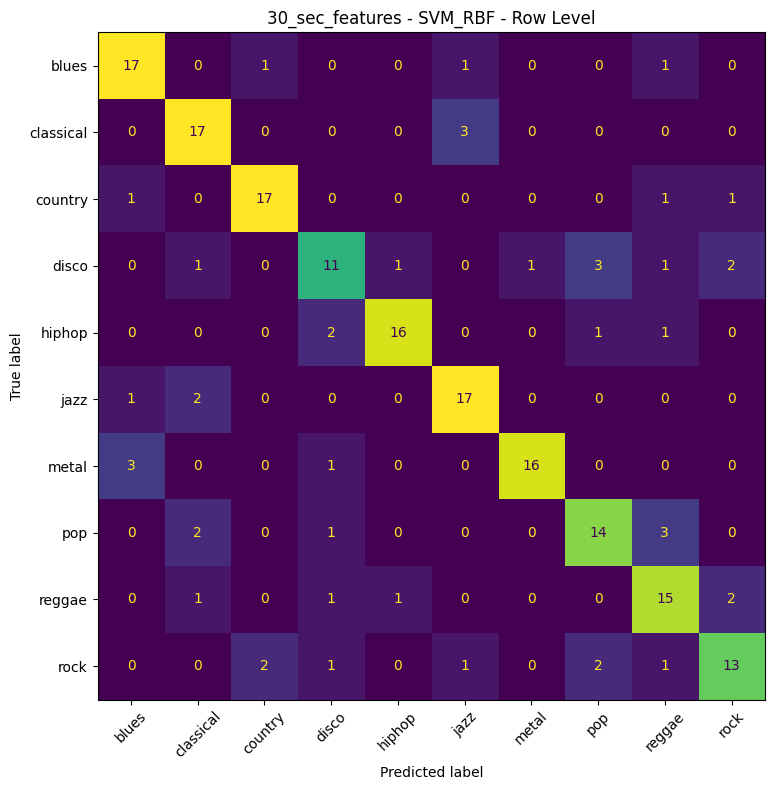


--- Training RandomForest on 30_sec_features ---

=== 30_sec_features | RandomForest | row_level ===
              precision    recall  f1-score   support

       blues       0.81      0.85      0.83        20
   classical       0.83      0.95      0.88        20
     country       0.80      0.80      0.80        20
       disco       0.76      0.65      0.70        20
      hiphop       0.71      0.75      0.73        20
        jazz       0.76      0.80      0.78        20
       metal       0.89      0.85      0.87        20
         pop       0.90      0.95      0.93        20
      reggae       0.80      0.80      0.80        20
        rock       0.76      0.65      0.70        20

    accuracy                           0.81       200
   macro avg       0.80      0.80      0.80       200
weighted avg       0.80      0.81      0.80       200



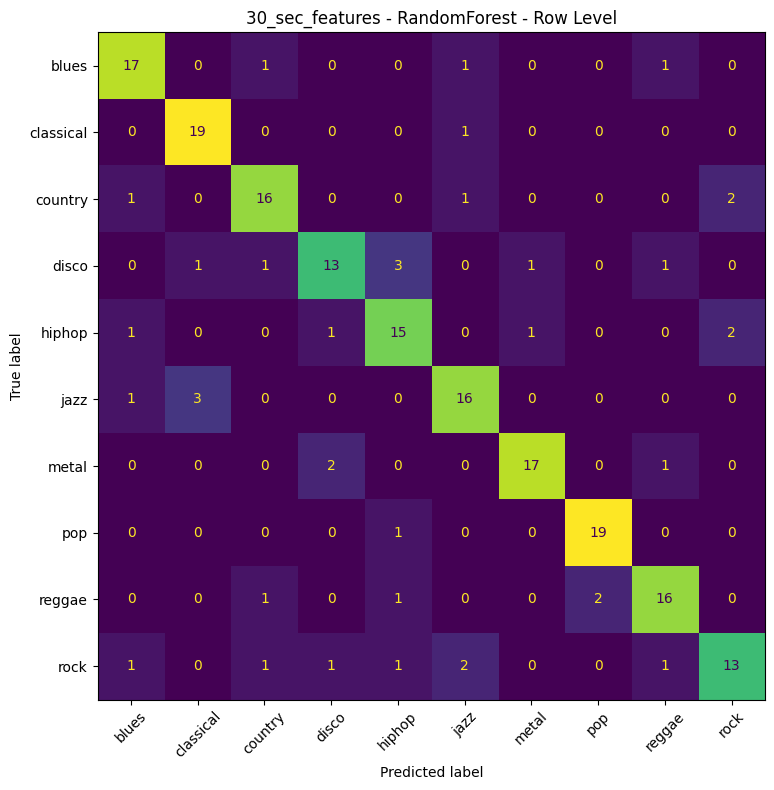


--- Training GradBoost on 30_sec_features ---

=== 30_sec_features | GradBoost | row_level ===
              precision    recall  f1-score   support

       blues       0.75      0.75      0.75        20
   classical       0.86      0.90      0.88        20
     country       0.68      0.85      0.76        20
       disco       0.68      0.65      0.67        20
      hiphop       0.71      0.75      0.73        20
        jazz       0.83      0.75      0.79        20
       metal       1.00      0.80      0.89        20
         pop       0.90      0.95      0.93        20
      reggae       0.80      0.80      0.80        20
        rock       0.63      0.60      0.62        20

    accuracy                           0.78       200
   macro avg       0.79      0.78      0.78       200
weighted avg       0.79      0.78      0.78       200



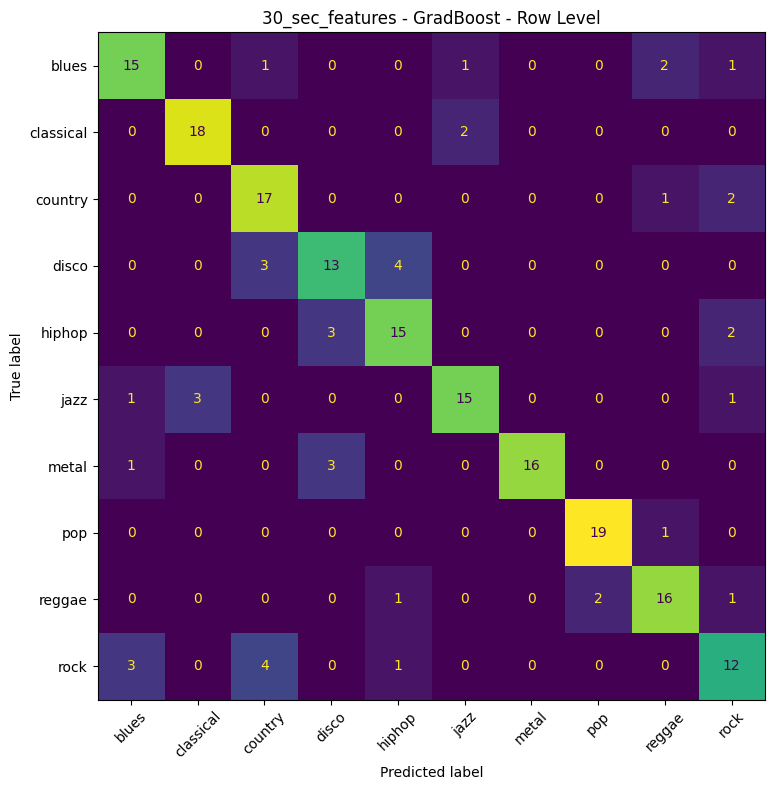


=== FINAL COMPARISON RESULTS ===
            dataset          evaluation         model  accuracy  macro_f1
0   30_sec_features           row_level  RandomForest    0.8050  0.802921
1   30_sec_features           row_level     GradBoost    0.7800  0.780255
2   30_sec_features           row_level       SVM_RBF    0.7650  0.764319
3   30_sec_features           row_level        LogReg    0.7400  0.740122
4    3_sec_features           row_level       SVM_RBF    0.7340  0.731510
5    3_sec_features           row_level  RandomForest    0.7180  0.714498
6    3_sec_features           row_level     GradBoost    0.7160  0.714480
7    3_sec_features           row_level        LogReg    0.6695  0.666699
8    3_sec_features  song_majority_vote       SVM_RBF    0.8300  0.827163
9    3_sec_features  song_majority_vote     GradBoost    0.8050  0.802677
10   3_sec_features  song_majority_vote  RandomForest    0.7800  0.777518
11   3_sec_features  song_majority_vote        LogReg    0.7600  0.754170

Sav

In [7]:


# ================================
# MAIN EXECUTION
# ================================
if __name__ == "__main__":

    # 1) Preprocess both datasets
    preprocess_gtzan_csv("features_3_sec.csv", "gtzan_3sec")
    preprocess_gtzan_csv("features_30_sec.csv", "gtzan_30sec")

    # 2) Train + compare
    df_3 = run_experiment("gtzan_3sec", "3_sec_features", song_level=True)
    df_30 = run_experiment("gtzan_30sec", "30_sec_features", song_level=False)

    results = pd.concat([df_3, df_30], ignore_index=True)

    results_sorted = results.sort_values(
        by=["dataset", "evaluation", "accuracy", "macro_f1"],
        ascending=[True, True, False, False]
    ).reset_index(drop=True)

    print("\n=== FINAL COMPARISON RESULTS ===")
    print(results_sorted)

    results_sorted.to_csv("gtzan_model_comparison.csv", index=False)
    print("\nSaved: gtzan_model_comparison.csv")
    print("Saved classification reports in: reports/")
    print("Saved confusion matrices in: confusion_matrices/")